# Extended Data Figure 4

Sam Gould, Kexin Dong

Cleaned: May 1, 2026

Last Updated: May 1, 2026

Benchmarking of MAGeCK and empirical null frameworks for ABE screen hit calling.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import scipy.stats
from sklearn.decomposition import PCA
from adjustText import adjust_text
from matplotlib_venn import venn2, venn3
from upsetplot import UpSet, from_indicators
import warnings
import os
warnings.filterwarnings('ignore')

# ── Global style (matching published figures) ─────────────────────────────────────────
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['text.usetex']  = False
plt.rcParams['font.family']     = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']

blues   = sns.color_palette('Blues').as_hex()
greens  = sns.color_palette('Greens').as_hex()
reds    = sns.color_palette('Reds').as_hex()
yellows = sns.color_palette('Oranges').as_hex()
purples = sns.color_palette('Purples').as_hex()

greys = sns.color_palette('Greys').as_hex()
teals = sns.color_palette('BuPu').as_hex()
pinks = sns.color_palette('RdPu').as_hex()
browns = sns.color_palette('YlOrBr').as_hex()
BASE = '/Users/kexindong/Documents/GitHub/B-ALL-in-vivo-base-editing/'

In [ ]:
BASE = '/Users/kexindong/Documents/GitHub/B-ALL-in-vivo-base-editing/'

dfs = {
    'ABE_OG':     pd.read_csv(BASE + 'LFC-FDR/ABE_OG_LFC_FDR.csv', low_memory=False),
    'CBE_OG':     pd.read_csv(BASE + 'LFC-FDR/CBE_OG_LFC_FDR.csv', low_memory=False),
    'ABE_EPO_T0': pd.read_csv(BASE + 'LFC-FDR/ABE_FC_EPO_T0_LFC_FDR.csv', low_memory=False),
    'CBE_EPO_T0': pd.read_csv(BASE + 'LFC-FDR/CBE_FC_EPO_T0_LFC_FDR.csv', low_memory=False),
    'ABE_EPO_BC': pd.read_csv(BASE + 'LFC-FDR/ABE_FC_EPO_TO_BC_LFC_FDR.csv', low_memory=False),
    'CBE_EPO_BC': pd.read_csv(BASE + 'LFC-FDR/CBE_FC_EPO_TO_BC_LFC_FDR.csv', low_memory=False),
    'ABE_BC_T0':  pd.read_csv(BASE + 'LFC-FDR/ABE_FC_BC_T0_LFC_FDR.csv', low_memory=False),
    'CBE_BC_T0':  pd.read_csv(BASE + 'LFC-FDR/CBE_FC_BC_T0_LFC_FDR.csv', low_memory=False),
}

# Conditions with FDR calculated
conds_og      = ['d15', 'bm', 'spleen', 'men']
conds_focused = ['d15', 'bm', 'spleen']

# Per-replicate raw count columns per condition per screen
rep_cols = {
    'ABE_OG':     {'bm':    ['bonemarrow1','bonemarrow2','bonemarrow3','bonemarrow4','bonemarrow5'],
                   'spleen':['spleen1','spleen2','spleen3','spleen4'],
                   'men':   ['meninges1','meninges2','meninges3','meninges4','meninges5'],
                   'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_OG':     {'bm':    ['bonemarrow1','bonemarrow2','bonemarrow3','bonemarrow4','bonemarrow5'],
                   'spleen':['spleen1','spleen2','spleen3','spleen4'],
                   'men':   ['meninges1','meninges2','meninges3','meninges4','meninges5'],
                   'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'ABE_EPO_T0': {'bm':    ['bm1','bm2','bm3','bm4','bm5'],
                   'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                   'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_EPO_T0': {'bm':    ['bm1','bm3','bm4','bm6','bm7','bm9','bm10'],
                   'spleen':['spleen1','spleen3','spleen4','spleen6','spleen7','spleen9','spleen10'],
                   'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'ABE_EPO_BC': {'bm':    ['bm1','bm3','bm5'],
                   'spleen':['spleen1','spleen3'],
                   'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_EPO_BC': {'bm':    ['bm1','bm3','bm4','bm6','bm7','bm9','bm10'],
                   'spleen':['spleen1','spleen3','spleen4','spleen6','spleen7','spleen9','spleen10'],
                   'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'ABE_BC_T0':  {'bm':    ['bm1','bm3','bm5'],
                   'spleen':['spleen1','spleen3'],
                   'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_BC_T0':  {'bm':    ['bm1','bm3','bm4','bm5','bm7','bm8','bm9'],
                   'spleen':['spleen1','spleen3','spleen4','spleen5','spleen7','spleen8','spleen9'],
                   'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
}

# COSMIC cancer gene census
cosmic = pd.read_csv(BASE + 'source-data/Census_allSun Nov 17 02_26_47 2024.csv').fillna('Undefined')
t_dict = {
    'TSG': 'TSG', 'TSG, fusion': 'TSG',
    'Undefined': 'Undefined', 'fusion': 'Undefined',
    'oncogene': 'Oncogene',
    'oncogene, TSG': 'Oncogene/TSG', 'oncogene, TSG, fusion': 'Oncogene/TSG',
    'oncogene, fusion': 'Oncogene',
}
color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple',
              'TSG':'tab:blue', 'Undefined':'tab:grey'}

def add_cosmic(df):
    gene_col = 'gene_name_h' if 'gene_name_h' in df.columns else 'Gene'
    roles = []
    for v in df[gene_col]:
        sub = cosmic[cosmic['Gene Symbol'] == v]
        roles.append('Undefined' if len(sub)==0 else t_dict.get(sub['Role in Cancer'].values[0], 'Undefined'))
    df = df.copy()
    df['Role in Cancer'] = roles
    df['color'] = [color_dict[r] for r in roles]
    return df

for key in dfs:
    dfs[key] = add_cosmic(dfs[key])

print('Loaded:')
for k, v in dfs.items():
    print(f'  {k}: {len(v)} guides')

Loaded:
  ABE_OG: 1070 guides
  CBE_OG: 13242 guides
  ABE_EPO_T0: 376 guides
  CBE_EPO_T0: 1257 guides
  ABE_EPO_BC: 376 guides
  CBE_EPO_BC: 1257 guides
  ABE_BC_T0: 376 guides
  CBE_BC_T0: 1257 guides


## 4a

Volcano plots of empirical −log10(FDR) versus median LFC (top) and MAGeCK −log10(FDR) versus MAGeCK LFC (bottom) for ABE gRNAs across all tissue contexts. No sensor editing cutoff applied. Dashed red lines indicate FDR = 0.1. Points are colored by hits classification: empirical framework only (blue), MAGeCK only (orange), called by both pipelines (red), or neither (gray).

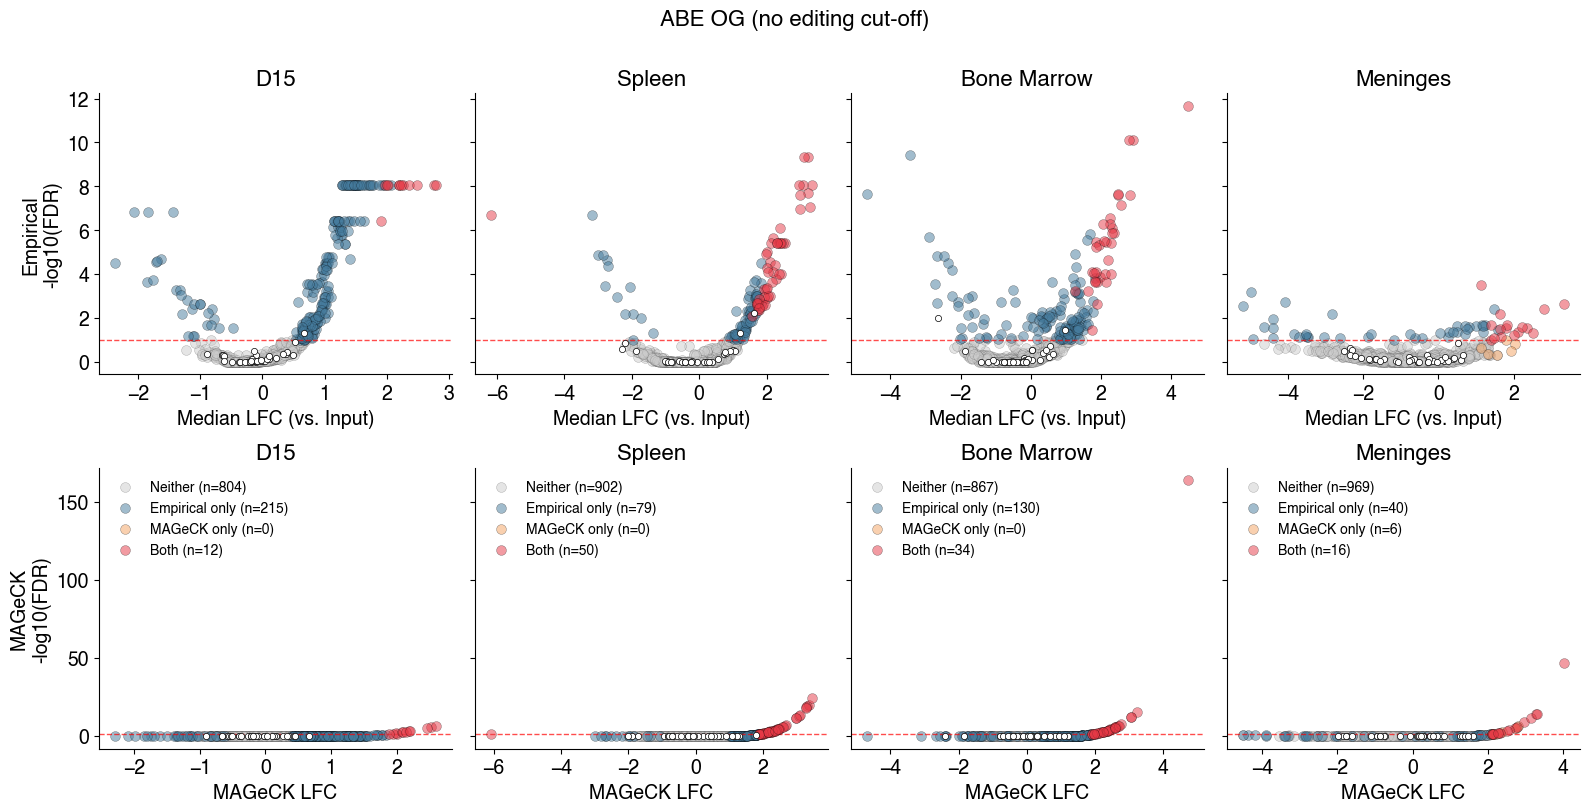

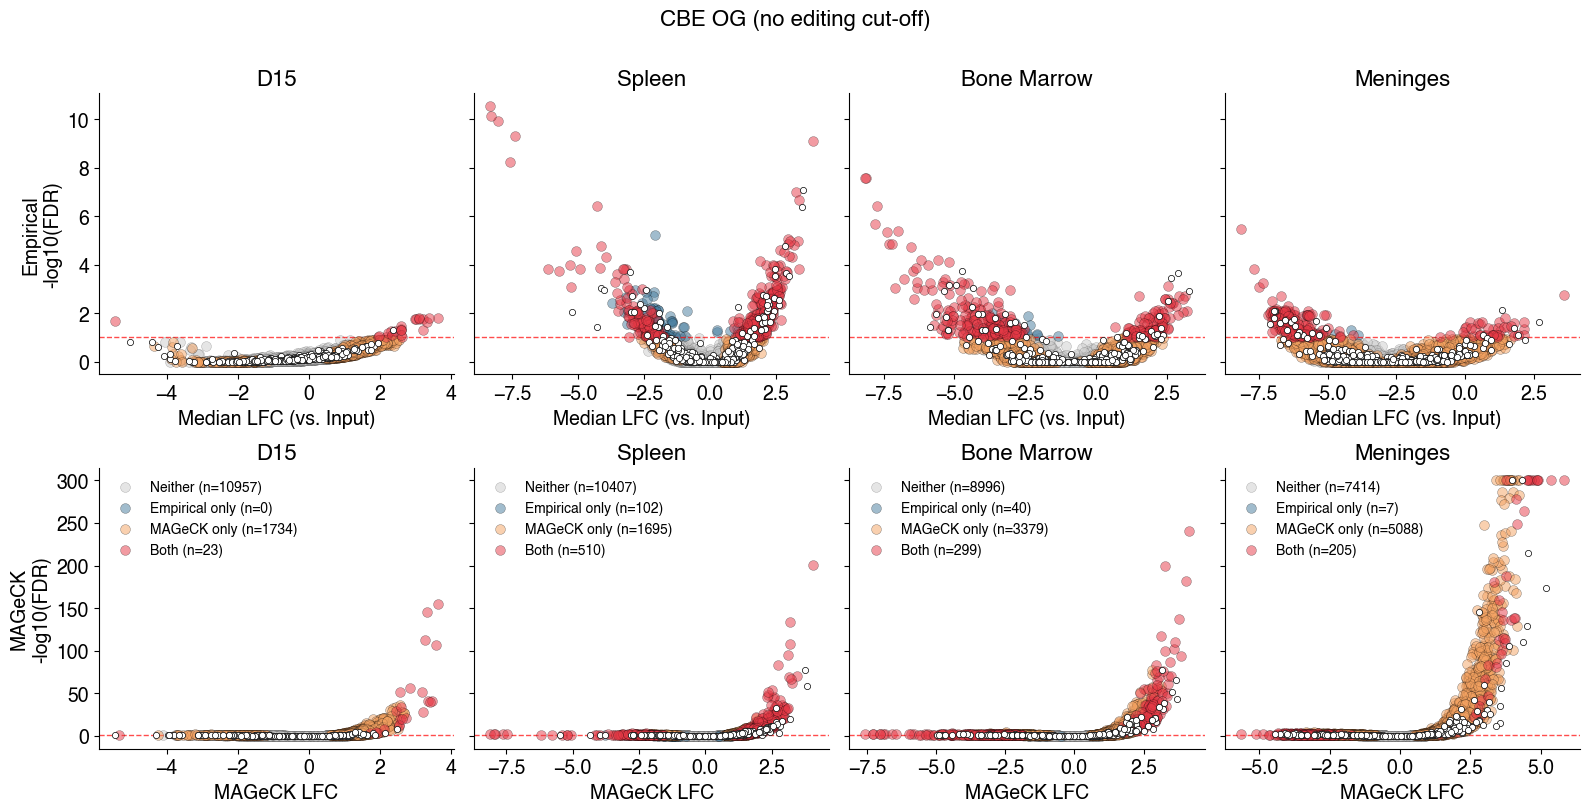

In [ ]:
# ── Volcano plots — OG ABE & CBE, ≥20% editing ──────────────────────────
# Color: Both hit / MAGeCK-only / Empirical-only / neither / controls (grey)
conditions_emp = ['d15', 'spleen', 'bm',          'men']
conditions_mag = ['d15', 'spleen', 'bonemarrow',   'meninges']
titles         = ['D15', 'Spleen', 'Bone Marrow',  'Meninges']
FDR_cutoff      = 0.1
min_input_counts = 5

# hit-category colors
cat_colors = {
    'Both':          '#e63946',
    'MAGeCK only':   '#f4a261',
    'Empirical only':'#457b9d',
    'Neither':       '#cccccc',
}
for editor, df_emp, mag_dict in [('ABE', dfs['ABE_OG'], ABE_mageck), ('CBE', dfs['CBE_OG'], CBE_mageck)]:
    ctrl_emp = df_emp[df_emp['classification'] != 'targeting guide'].copy()
    targ_emp = df_emp[
        (df_emp['classification'] == 'targeting guide') &
        # editing threshold
        # (df_emp['target_base_edit_perc_d5'] >= 20) &
        (df_emp['Input_median'] >= min_input_counts)
    ].copy()

    fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey='row')

    for k, (emp_cond, mag_cond, title) in enumerate(zip(conditions_emp, conditions_mag, titles)):
        emp_fdr_col = f'FDR_{emp_cond}_fishers'
        emp_lfc_col = f'LFC_median_{emp_cond}'

        # merge empirical targets with MAGeCK FDR
        mag = mag_dict[mag_cond][['gRNA_id', 'LFC', 'FDR']].rename(columns={'LFC': 'mag_LFC', 'FDR': 'mag_FDR'})
        merged = pd.merge(targ_emp[['gRNA_id', emp_lfc_col, emp_fdr_col]], mag, on='gRNA_id', how='inner')

        emp_hit = merged[emp_fdr_col] < FDR_cutoff
        mag_hit = merged['mag_FDR']   < FDR_cutoff
        merged['category'] = 'Neither'
        merged.loc[emp_hit & ~mag_hit, 'category'] = 'Empirical only'
        merged.loc[~emp_hit & mag_hit, 'category'] = 'MAGeCK only'
        merged.loc[emp_hit & mag_hit,  'category'] = 'Both'

        # also compute empirical nlog10 for controls
        ctrl_emp[f'nlog10_{emp_cond}'] = -np.log10(ctrl_emp[emp_fdr_col].clip(lower=1e-300))
        merged['nlog10_emp'] = -np.log10(merged[emp_fdr_col].clip(lower=1e-300))
        merged['nlog10_mag'] = -np.log10(merged['mag_FDR'].clip(lower=1e-300))

        for row_idx, (ax, y_col, x_col, ylabel) in enumerate([
            (axes[0][k], 'nlog10_emp', emp_lfc_col, 'Empirical\n-log10(FDR)'),
            (axes[1][k], 'nlog10_mag', 'mag_LFC',   'MAGeCK\n-log10(FDR)'),
        ]):
            # plot in order: Neither first, then singles, then Both on top
            for cat in ['Neither', 'Empirical only', 'MAGeCK only', 'Both']:
                sub = merged[merged['category'] == cat]
                ax.scatter(sub[x_col], sub[y_col],
                           color=cat_colors[cat], edgecolor='black' if cat != 'Neither' else greys[4],
                           linewidth=0.3, s=50,
                           alpha=0.5,
                           zorder=1 if cat == 'Neither' else 2 + ['Empirical only','MAGeCK only','Both'].index(cat),
                           label=f'{cat} (n={len(sub)})')
        #    controls
            if row_idx == 0:
                ax.scatter(ctrl_emp[emp_lfc_col], ctrl_emp[f'nlog10_{emp_cond}'],
                           color='white', edgecolor='black', linewidth=.5, s=20, alpha=1, zorder=6)
            else:
                ctrl_mag = pd.merge(ctrl_emp[['gRNA_id', emp_lfc_col]], mag, on='gRNA_id', how='inner')
                ctrl_mag['nlog10_mag'] = -np.log10(ctrl_mag['mag_FDR'].clip(lower=1e-300))
                ax.scatter(ctrl_mag['mag_LFC'], ctrl_mag['nlog10_mag'],
                           color='white', edgecolor='black', linewidth=.5, s=20, alpha=1, zorder=6)

            ax.axhline(-np.log10(FDR_cutoff), color='red', linestyle='--', linewidth=1, alpha=0.7)
            ax.set_title(title, fontsize=16)
            ax.spines[['top', 'right']].set_visible(False)
            ax.tick_params(axis='both', which='major', labelsize=14)
            ax.set_xlabel('Median LFC (vs. Input)' if row_idx == 0 else 'MAGeCK LFC', fontsize=14)
            if k == 0:
                ax.set_ylabel(ylabel, fontsize=14)
            if row_idx == 1:
                ax.legend(fontsize=10, frameon=False, loc='upper left')

    fig.suptitle(f'{editor} OG (no editing cut-off)', fontsize=16, y=1.01)
    fig.tight_layout()
    plt.savefig(f'figures_final/volcano_comparison_{editor}_OG_no_editing_cut.png', bbox_inches='tight', dpi=600)
    plt.show()

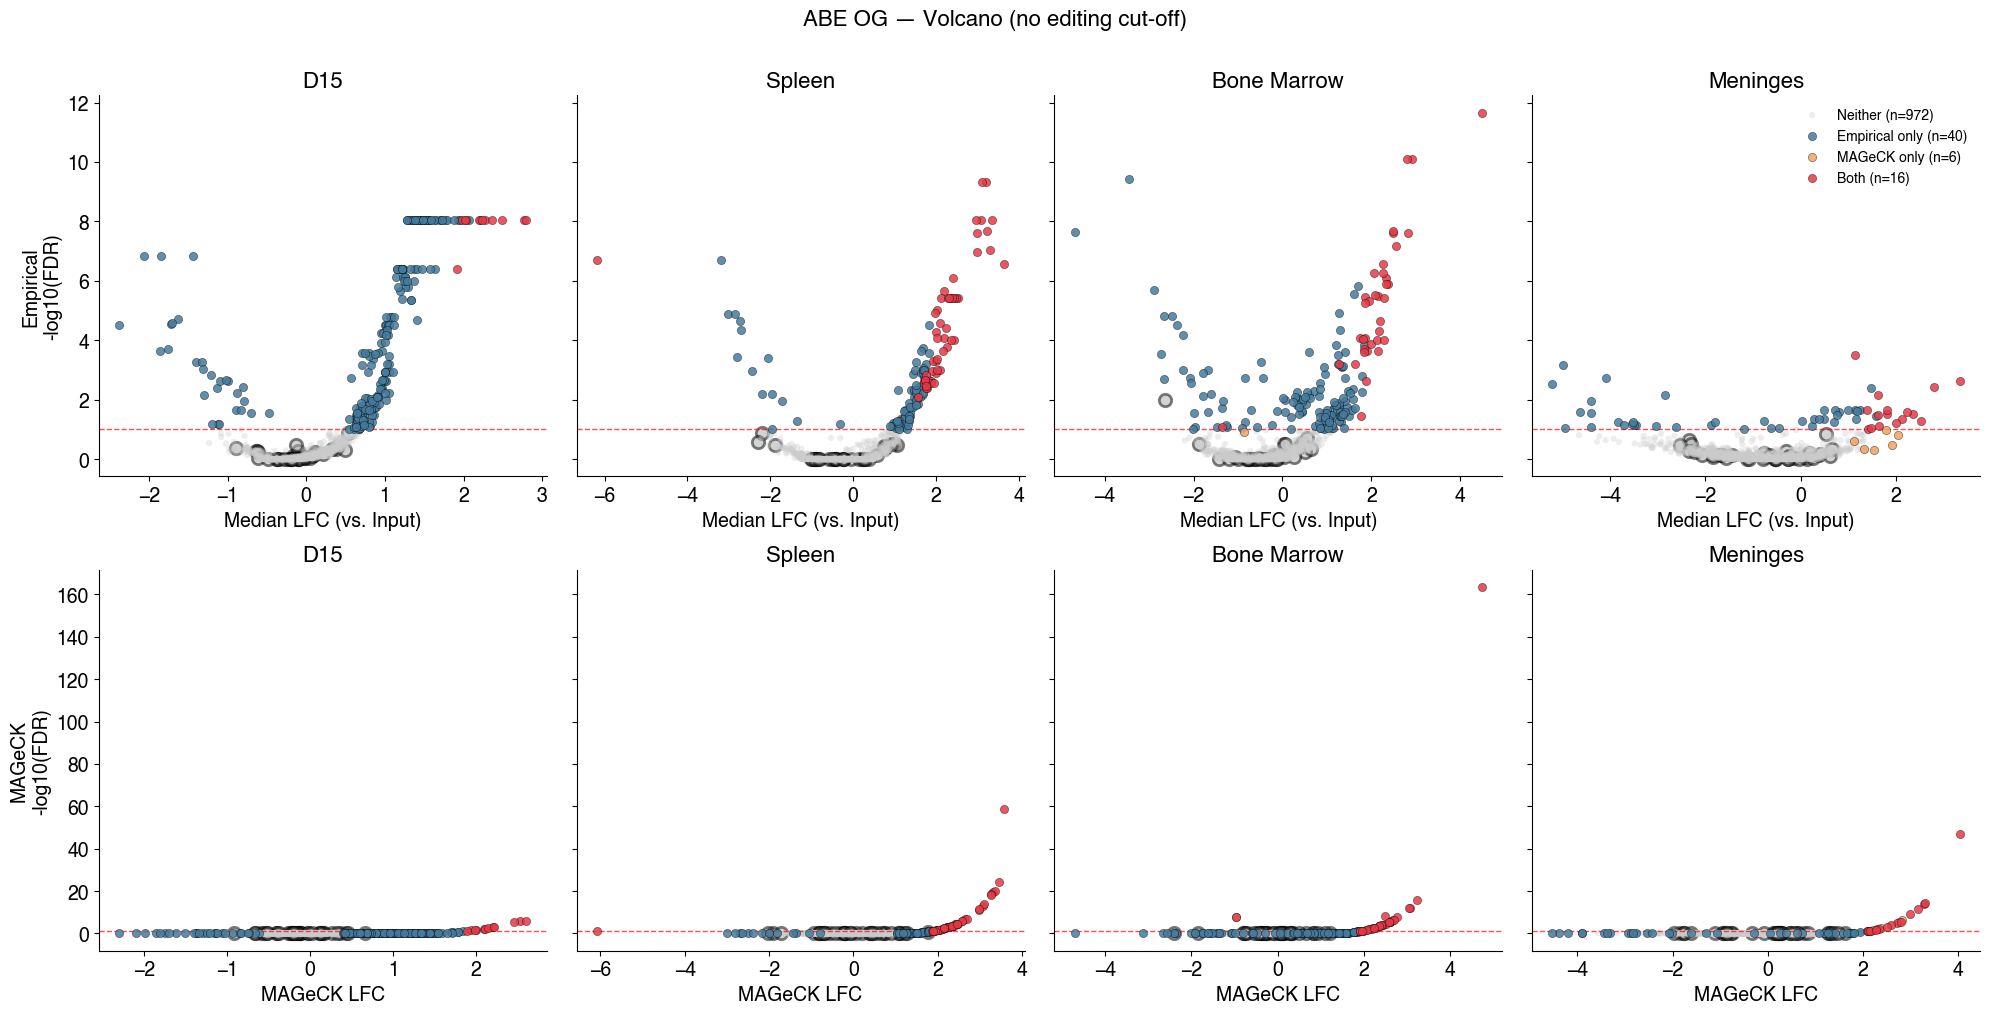

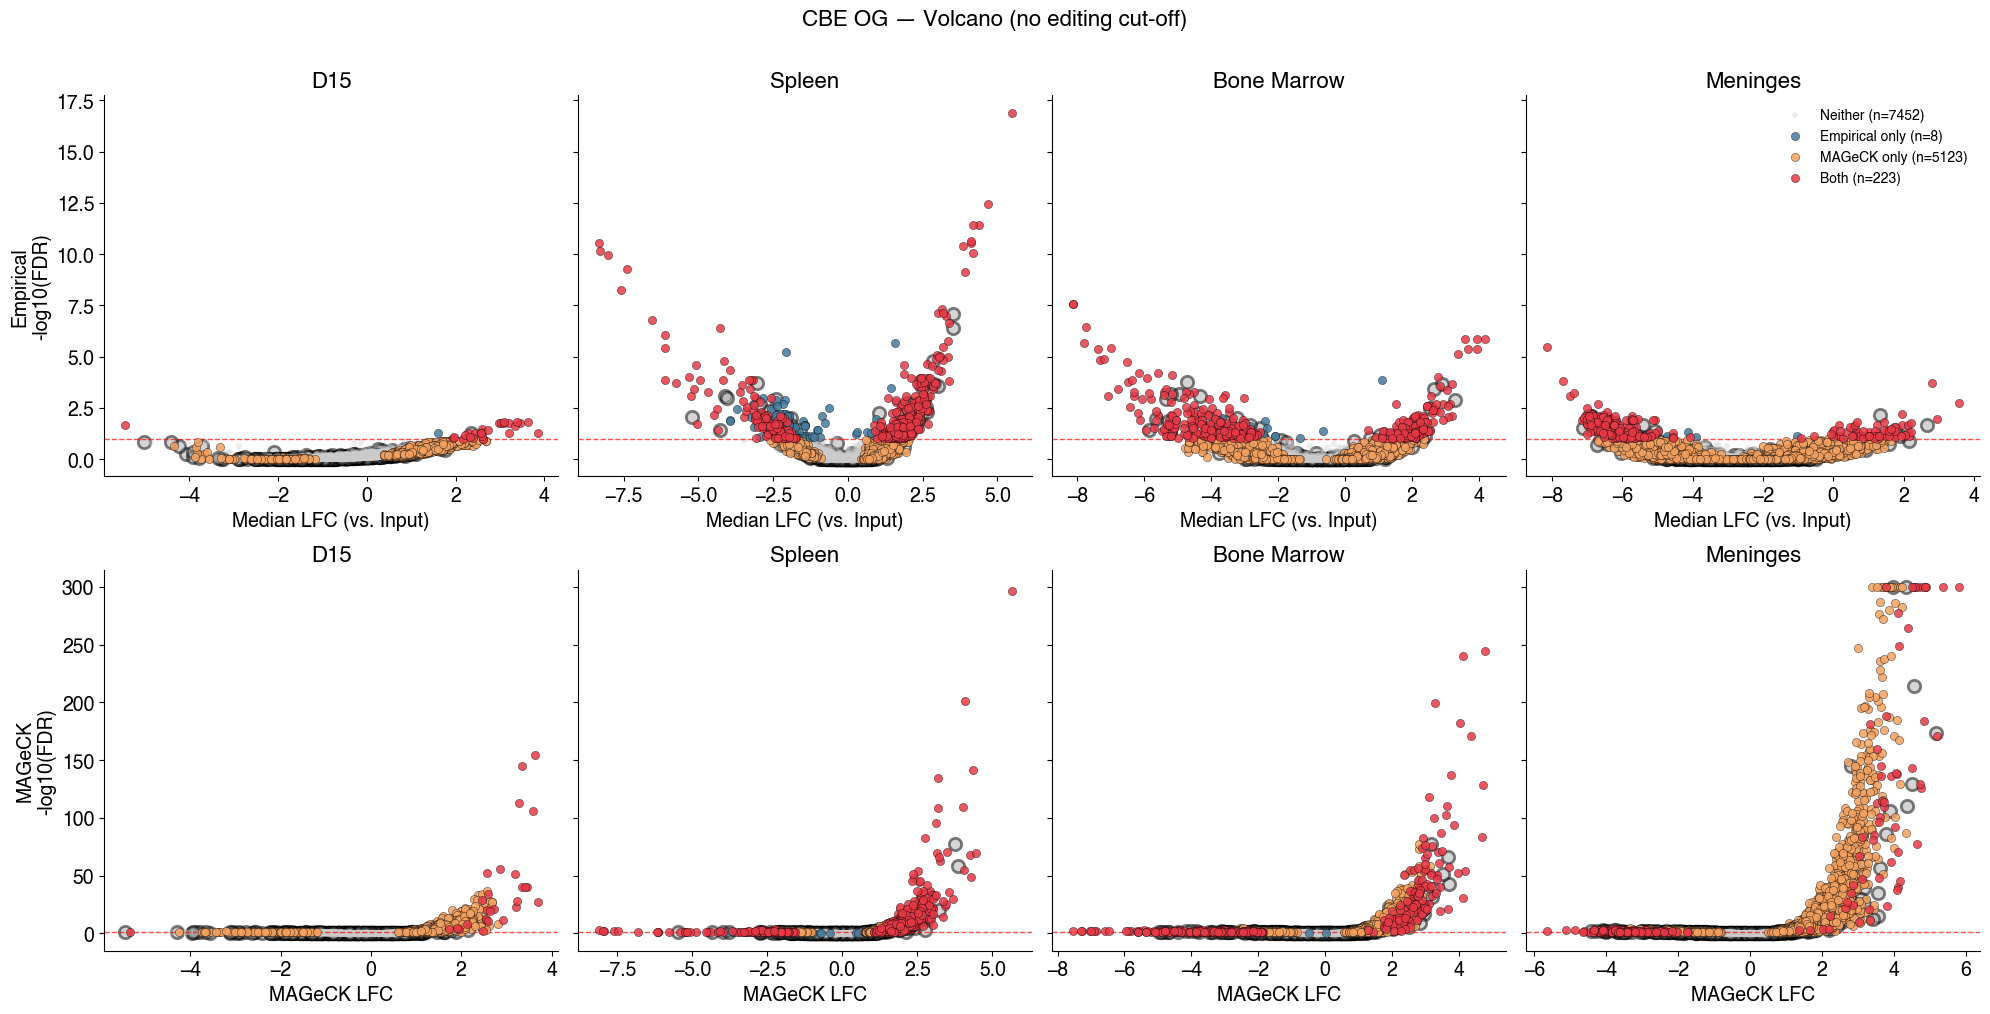

In [ ]:
# ── Volcano plots — OG ABE & CBE, no editing cut-off ──────────────────────────
# Color: Both hit / MAGeCK-only / Empirical-only / neither / controls (grey)

conditions_emp = ['d15', 'spleen', 'bm',          'men']
conditions_mag = ['d15', 'spleen', 'bonemarrow',   'meninges']
titles         = ['D15', 'Spleen', 'Bone Marrow',  'Meninges']
FDR_cutoff      = 0.1
min_input_counts = 2

# hit-category colors
cat_colors = {
    'Both':          '#e63946',
    'MAGeCK only':   '#f4a261',
    'Empirical only':'#457b9d',
    'Neither':       '#cccccc',
}

for editor, df_emp, mag_dict in [('ABE', dfs['ABE_OG'], ABE_mageck), ('CBE', dfs['CBE_OG'], CBE_mageck)]:
    ctrl_emp = df_emp[df_emp['classification'] != 'targeting guide'].copy()
    targ_emp = df_emp[df_emp['classification'] == 'targeting guide'].copy()

    fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharey='row')

    for k, (emp_cond, mag_cond, title) in enumerate(zip(conditions_emp, conditions_mag, titles)):
        emp_fdr_col = f'FDR_{emp_cond}_fishers'
        emp_lfc_col = f'LFC_median_{emp_cond}'

        # merge empirical targets with MAGeCK FDR
        mag = mag_dict[mag_cond][['gRNA_id', 'LFC', 'FDR']].rename(columns={'LFC': 'mag_LFC', 'FDR': 'mag_FDR'})
        merged = pd.merge(targ_emp[['gRNA_id', emp_lfc_col, emp_fdr_col]], mag, on='gRNA_id', how='inner')

        emp_hit = merged[emp_fdr_col] < FDR_cutoff
        mag_hit = merged['mag_FDR']   < FDR_cutoff
        merged['category'] = 'Neither'
        merged.loc[emp_hit & ~mag_hit, 'category'] = 'Empirical only'
        merged.loc[~emp_hit & mag_hit, 'category'] = 'MAGeCK only'
        merged.loc[emp_hit & mag_hit,  'category'] = 'Both'

        # also compute empirical nlog10 for controls
        ctrl_emp[f'nlog10_{emp_cond}'] = -np.log10(ctrl_emp[emp_fdr_col].clip(lower=1e-300))
        merged['nlog10_emp'] = -np.log10(merged[emp_fdr_col].clip(lower=1e-300))
        merged['nlog10_mag'] = -np.log10(merged['mag_FDR'].clip(lower=1e-300))

        for row_idx, (ax, y_col, x_col, ylabel) in enumerate([
            (axes[0][k], 'nlog10_emp', emp_lfc_col, 'Empirical\n-log10(FDR)'),
            (axes[1][k], 'nlog10_mag', 'mag_LFC',   'MAGeCK\n-log10(FDR)'),
        ]):
            # controls
            if row_idx == 0:
                ax.scatter(ctrl_emp[emp_lfc_col], ctrl_emp[f'nlog10_{emp_cond}'],
                           color='#aaaaaa', edgecolor='black', linewidth=2, s=80, alpha=0.5, zorder=1)
            else:
                ctrl_mag = pd.merge(ctrl_emp[['gRNA_id', emp_lfc_col]], mag, on='gRNA_id', how='inner')
                ctrl_mag['nlog10_mag'] = -np.log10(ctrl_mag['mag_FDR'].clip(lower=1e-300))
                ax.scatter(ctrl_mag['mag_LFC'], ctrl_mag['nlog10_mag'],
                           color='#aaaaaa', edgecolor='black', linewidth=2, s=80, alpha=0.5, zorder=1)

            # plot in order: Neither first, then singles, then Both on top
            for cat in ['Neither', 'Empirical only', 'MAGeCK only', 'Both']:
                sub = merged[merged['category'] == cat]
                ax.scatter(sub[x_col], sub[y_col],
                           color=cat_colors[cat], edgecolor='black' if cat != 'Neither' else 'none',
                           linewidth=0.3, s=20 if cat == 'Neither' else 35,
                           alpha=0.35 if cat == 'Neither' else 0.85,
                           zorder=2 if cat == 'Neither' else 3 + ['Empirical only','MAGeCK only','Both'].index(cat),
                           label=f'{cat} (n={len(sub)})')

            ax.axhline(-np.log10(FDR_cutoff), color='red', linestyle='--', linewidth=1, alpha=0.7)
            ax.set_title(title, fontsize=16)
            ax.spines[['top', 'right']].set_visible(False)
            ax.tick_params(axis='both', which='major', labelsize=14)
            ax.set_xlabel('Median LFC (vs. Input)' if row_idx == 0 else 'MAGeCK LFC', fontsize=14)
            if k == 0:
                ax.set_ylabel(ylabel, fontsize=14)
            if k == 3 and row_idx == 0:
                ax.legend(fontsize=10, frameon=False, loc='upper right')

    fig.suptitle(f'{editor} OG — Volcano (no editing cut-off)', fontsize=16, y=1.01)
    fig.tight_layout()
    plt.show()


## 4b

Venn diagrams comparing significant hits (FDR < 0.1) identified by MAGeCK versus the empirical framework for ABE gRNAs across all tissue contexts.

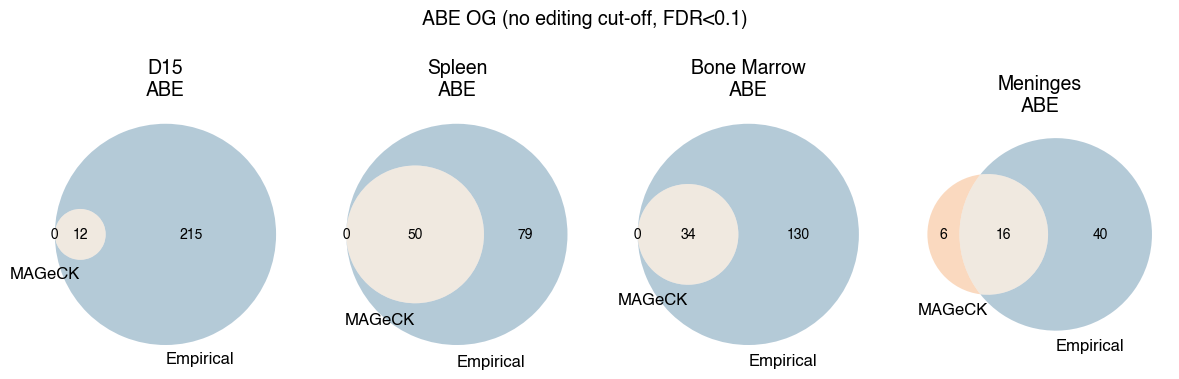

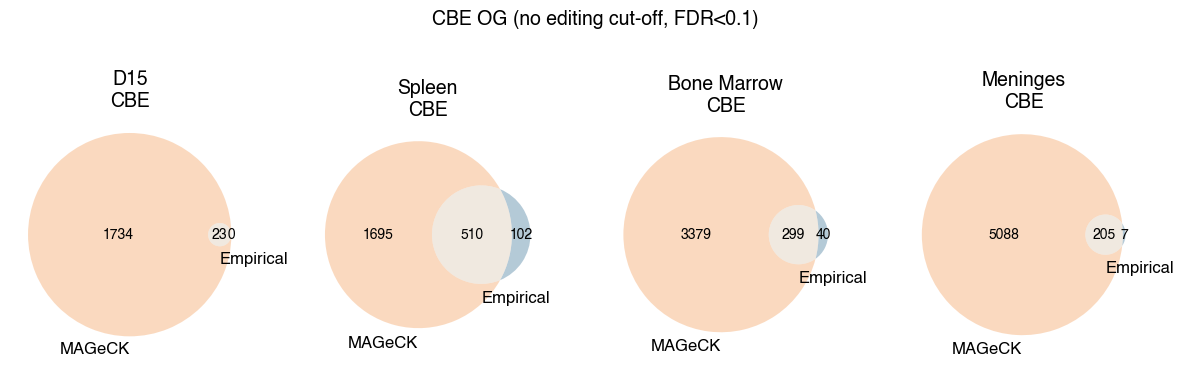

In [ ]:
from matplotlib_venn import venn2

conditions_emp = ['d15', 'spleen', 'bm',        'men']
conditions_mag = ['d15', 'spleen', 'bonemarrow', 'meninges']
titles         = ['D15', 'Spleen', 'Bone Marrow', 'Meninges']
FDR_cutoff      = 0.1
min_input_counts = 5

for editor, df_emp, mag_dict in [('ABE', dfs['ABE_OG'], ABE_mageck),
                                   ('CBE', dfs['CBE_OG'], CBE_mageck)]:
    # target guides only, no editing filter
    targ = df_emp[
        (df_emp['classification'] == 'targeting guide') &
        (df_emp['Input_median'] >= min_input_counts)
    ]

    fig, axes = plt.subplots(1, 4, figsize=(12, 4))

    for k, (emp_cond, mag_cond, title) in enumerate(zip(conditions_emp, conditions_mag, titles)):
        emp_fdr_col = f'FDR_{emp_cond}_fishers'

        mag = mag_dict[mag_cond][['gRNA_id', 'FDR']].rename(columns={'FDR': 'mag_FDR'})
        merged = pd.merge(targ[['gRNA_id', emp_fdr_col]], mag, on='gRNA_id', how='inner')

        emp_hits = set(merged.loc[merged[emp_fdr_col] < FDR_cutoff, 'gRNA_id'])
        mag_hits = set(merged.loc[merged['mag_FDR']   < FDR_cutoff, 'gRNA_id'])

        venn2([mag_hits, emp_hits],
              set_labels=('MAGeCK', 'Empirical'),
              set_colors=('#f4a261', '#457b9d'),
              ax=axes[k])
        axes[k].set_title(f'{title}\n{editor}', fontsize=14)

    fig.suptitle(f'{editor} OG (no editing cut-off, FDR<0.1)', fontsize=14, y=1.02)
    fig.tight_layout()
    plt.savefig(f'figures_final/venn_comparison_{editor}_OG_no_editing_cut.png', bbox_inches='tight', dpi=600)
    plt.show()

## 4c

Heatmap of pairwise Spearman correlation coefficients between per-replicate empirical LFC z-scores for all ABE samples across bone marrow, spleen, meninges, and in vitro conditions.

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


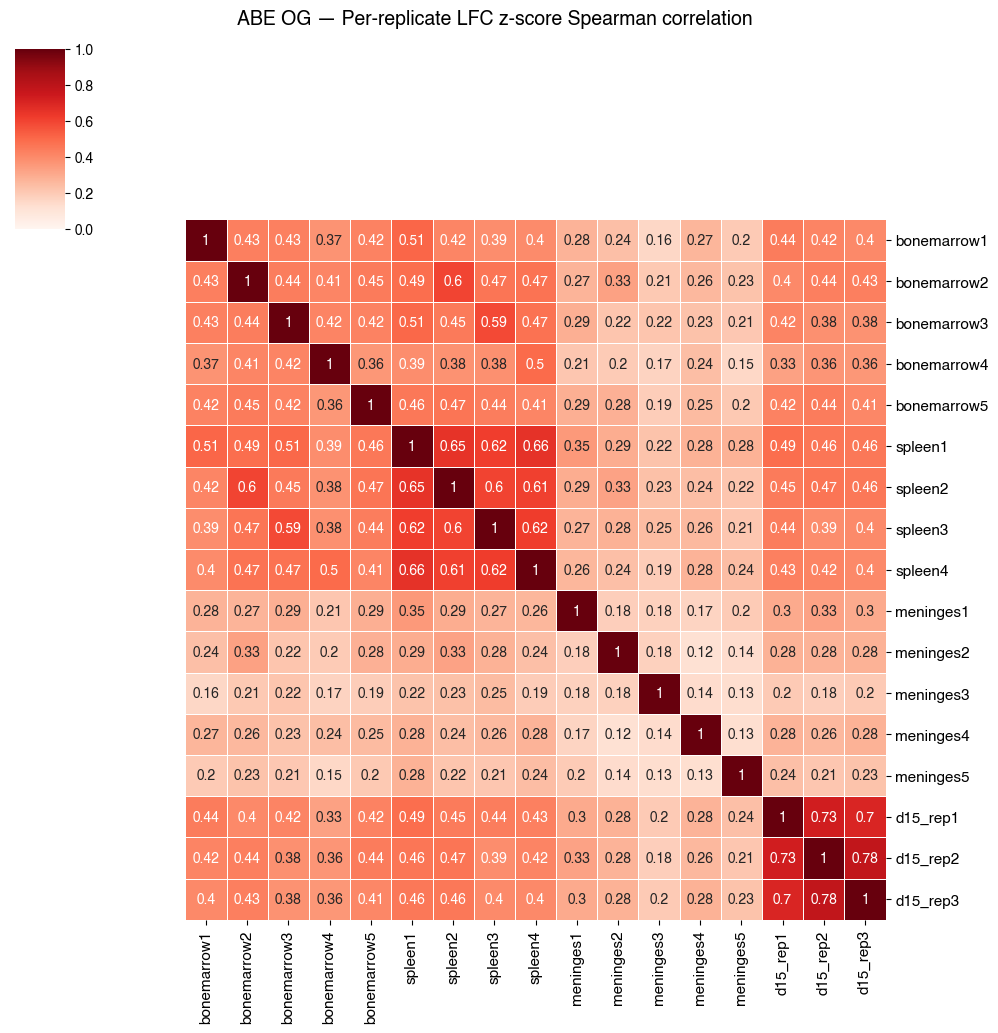

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


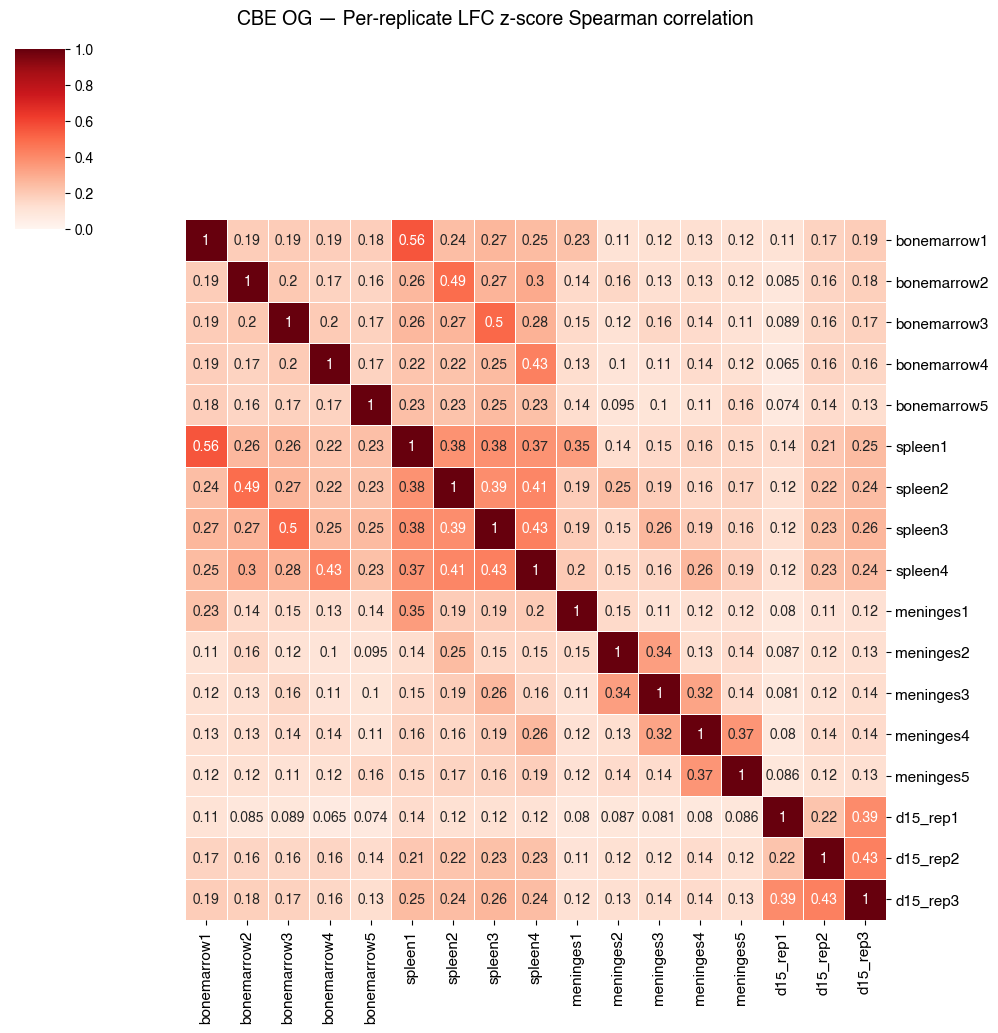

In [ ]:
# ── Per-replicate LFC z-score correlation clustermaps ────────────────────
# rep_cols defined in cell 25; keys: 'bm', 'spleen', 'men', 'd15'
min_input = 5

for editor in ['ABE', 'CBE']:
    df = dfs[f'{editor}_OG']
    targ = df[(df['classification'] == 'targeting guide') & (df['Input_median'] >= min_input)].copy()

    # Collect all replicate LFC columns for this editor
    all_rep_cols = []
    all_rep_labels = []
    for cond, cols in rep_cols[f'{editor}_OG'].items():
        for col in cols:
            all_rep_cols.append(col)
            all_rep_labels.append(col)

    rep_data = targ[all_rep_cols].dropna()

    # Convert each replicate to z-score across guides
    from scipy.stats import zscore
    rep_z = rep_data.apply(zscore, nan_policy='omit')
    rep_z.columns = all_rep_labels

    corr = rep_z.corr(method='spearman')

    g = sns.clustermap(corr, cmap='Reds', vmin=0, vmax=1,
                       annot=True, linewidth=0.5, annot_kws={'size': 10},row_cluster=False, col_cluster=False,
                       figsize=(10, 10))
    g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xmajorticklabels(), fontsize=11, rotation=90)
    g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_ymajorticklabels(), fontsize=11, rotation=0)
    g.fig.suptitle(f'{editor} OG — Per-replicate LFC z-score Spearman correlation', y=1.02, fontsize=14)
    g.savefig(BASE + f'figures_final/clustermap_{editor}_rep_zscore.pdf', bbox_inches='tight')
    plt.show()

## 4d

Volcano plot of ABE sgRNA enrichment and depletion in spleen. Axes show median LFC versus empirical −log10(FDR). Enriched (orange) and depleted (blue) gRNAs targeting leukemia-related genes are labeled.

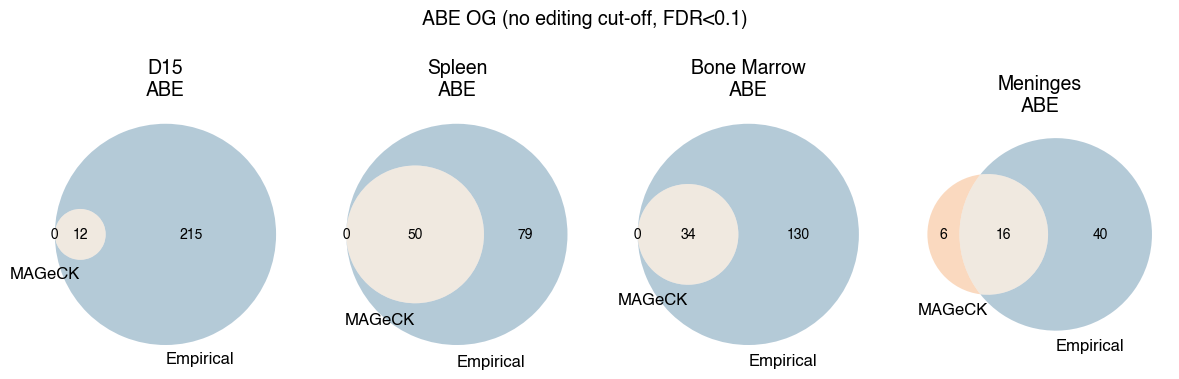

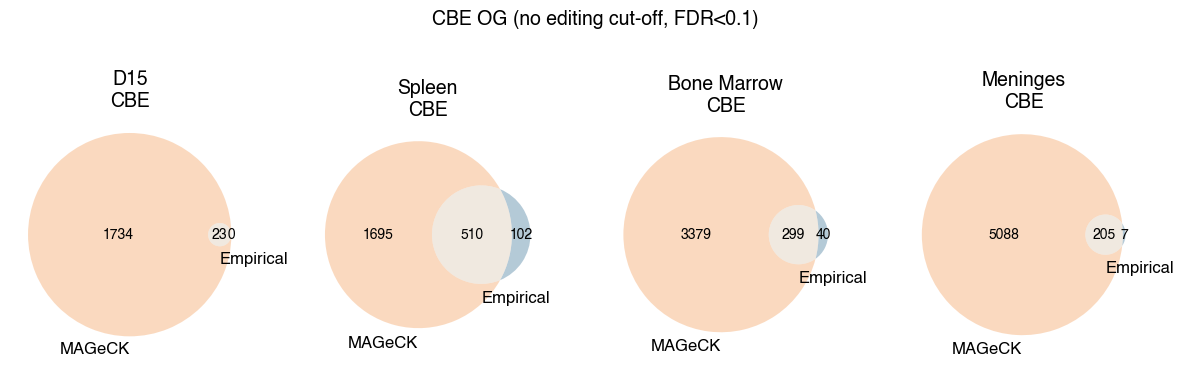

In [ ]:
from matplotlib_venn import venn2

conditions_emp = ['d15', 'spleen', 'bm',        'men']
conditions_mag = ['d15', 'spleen', 'bonemarrow', 'meninges']
titles         = ['D15', 'Spleen', 'Bone Marrow', 'Meninges']
FDR_cutoff      = 0.1
min_input_counts = 5

for editor, df_emp, mag_dict in [('ABE', dfs['ABE_OG'], ABE_mageck),
                                   ('CBE', dfs['CBE_OG'], CBE_mageck)]:
    # target guides only, no editing filter
    targ = df_emp[
        (df_emp['classification'] == 'targeting guide') &
        (df_emp['Input_median'] >= min_input_counts)
    ]

    fig, axes = plt.subplots(1, 4, figsize=(12, 4))

    for k, (emp_cond, mag_cond, title) in enumerate(zip(conditions_emp, conditions_mag, titles)):
        emp_fdr_col = f'FDR_{emp_cond}_fishers'

        mag = mag_dict[mag_cond][['gRNA_id', 'FDR']].rename(columns={'FDR': 'mag_FDR'})
        merged = pd.merge(targ[['gRNA_id', emp_fdr_col]], mag, on='gRNA_id', how='inner')

        emp_hits = set(merged.loc[merged[emp_fdr_col] < FDR_cutoff, 'gRNA_id'])
        mag_hits = set(merged.loc[merged['mag_FDR']   < FDR_cutoff, 'gRNA_id'])

        venn2([mag_hits, emp_hits],
              set_labels=('MAGeCK', 'Empirical'),
              set_colors=('#f4a261', '#457b9d'),
              ax=axes[k])
        axes[k].set_title(f'{title}\n{editor}', fontsize=14)

    fig.suptitle(f'{editor} OG (no editing cut-off, FDR<0.1)', fontsize=14, y=1.02)
    fig.tight_layout()
    plt.savefig(f'figures_final/venn_comparison_{editor}_OG_no_editing_cut.png', bbox_inches='tight', dpi=600)
    plt.show()